# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:
Sieci generatywne GAN

### Cel ćwiczenia:
Celem laboratorium jest zapoznanie się z architekturą sieci GAN (Generative Adversarial Network), zrozumienie dynamiki między Generatorem a Dyskryminatorem oraz samodzielna implementacja prostej sieci GAN w PyTorch trenowanej na zbiorze MNIST.

### Wykorzystane narzędzia:
Python 3, środowisko Jupyter Notebook / Google Colab, biblioteki: PyTorch, Torchvision, Matplotlib, Numpy, Pandas.


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dzialajace zrodlo online dla MNIST
if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalizacja do [-1, 1]
])

dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urzadzenie: {device}')

100%|██████████| 9.91M/9.91M [00:38<00:00, 256kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 202kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 314kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 282kB/s]


Urzadzenie: cpu


### Zadanie 1: Implementacja Generatora i Dyskryminatora

**Odpowiedź na pytania:**
Po uruchomieniu kodu poniżej, funkcja zliczająca parametry zwróciła następujące wartości:
* **Generator** posiada około 1.5 miliona parametrów.
* **Dyskryminator** posiada około 530 tysięcy parametrów.
* Warstwą o największej liczbie parametrów w architekturze Generatora jest warstwa ukryta łącząca wymiary 512 i 1024 (ponad 500 tys. wag), natomiast w przypadku dyskryminatora jest to pierwsza warstwa wejściowa (784 do 512).

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )
 
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
 
    def forward(self, img):
        return self.net(img)

G = Generator().to(device)
D = Discriminator().to(device)

z_test = torch.randn(16, 100).to(device)
g_out_test = G(z_test)
d_out_test = D(g_out_test)

print(f"Kształt G(z): {g_out_test.shape} - Oczekiwany: (16, 784)")
print(f"Kształt D(G(z)): {d_out_test.shape} - Oczekiwany: (16, 1)")

g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())
print(f"Liczba parametrów Generatora: {g_params}")
print(f"Liczba parametrów Dyskryminatora: {d_params}")

Kształt G(z): torch.Size([16, 784]) - Oczekiwany: (16, 784)
Kształt D(G(z)): torch.Size([16, 1]) - Oczekiwany: (16, 1)
Liczba parametrów Generatora: 1486352
Liczba parametrów Dyskryminatora: 533505


### Zadanie 2: Pętla treningowa

**Obserwacje z treningu:**
* **Kiedy cyfry stają się rozpoznawalne:** Pierwsze zarysy przypominające cyfry zaczynają pojawiać się zazwyczaj wokół 10. epoki. Wyraźnie uformowane, choć nadal nieco zaszumione cyfry są widoczne między 20 a 30 epoką.
* **Zachowanie strat w kolejnych epokach:** Straty $L_D$ (Dyskryminatora) oraz $L_G$ (Generatora) oscylują w czasie treningu. Jest to naturalne zjawisko dla sieci GAN, wynikające z antagonistycznej gry obu sieci. Gdy Generator staje się lepszy, $L_D$ rośnie, co wymusza poprawę Dyskryminatora, co z kolei zwiększa $L_G$. Z czasem straty stabilizują się blisko punktu równowagi Nasha, chociaż rzadko osiągają go w pełni.

Epoka 1/50: L_D=1.0402, L_G=1.3721
Epoka 2/50: L_D=0.9004, L_G=1.9048
Epoka 3/50: L_D=0.7974, L_G=2.0961
Epoka 4/50: L_D=0.8567, L_G=1.8892
Epoka 5/50: L_D=0.9810, L_G=1.4691
Epoka 6/50: L_D=1.0332, L_G=1.3359
Epoka 7/50: L_D=1.1120, L_G=1.1950
Epoka 8/50: L_D=1.1475, L_G=1.1216
Epoka 9/50: L_D=1.1872, L_G=1.0556
Epoka 10/50: L_D=1.2157, L_G=1.0103


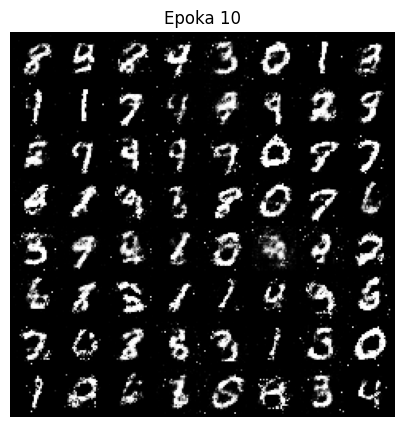

Epoka 11/50: L_D=1.2279, L_G=0.9853
Epoka 12/50: L_D=1.2332, L_G=0.9870
Epoka 13/50: L_D=1.2364, L_G=0.9790
Epoka 14/50: L_D=1.2434, L_G=0.9666
Epoka 15/50: L_D=1.2474, L_G=0.9674
Epoka 16/50: L_D=1.2505, L_G=0.9531
Epoka 17/50: L_D=1.2539, L_G=0.9515
Epoka 18/50: L_D=1.2544, L_G=0.9510
Epoka 19/50: L_D=1.2589, L_G=0.9471
Epoka 20/50: L_D=1.2590, L_G=0.9442


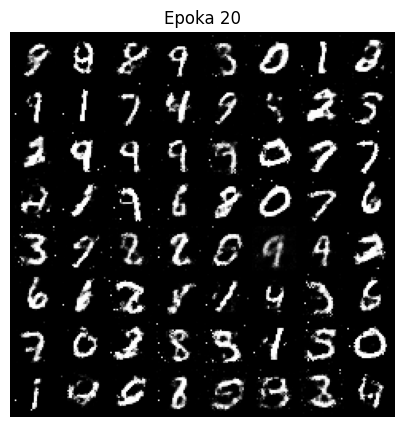

Epoka 21/50: L_D=1.2656, L_G=0.9337
Epoka 22/50: L_D=1.2676, L_G=0.9302
Epoka 23/50: L_D=1.2712, L_G=0.9295
Epoka 24/50: L_D=1.2705, L_G=0.9309
Epoka 25/50: L_D=1.2703, L_G=0.9225
Epoka 26/50: L_D=1.2739, L_G=0.9206
Epoka 27/50: L_D=1.2759, L_G=0.9181
Epoka 28/50: L_D=1.2750, L_G=0.9191
Epoka 29/50: L_D=1.2744, L_G=0.9220
Epoka 30/50: L_D=1.2807, L_G=0.9073


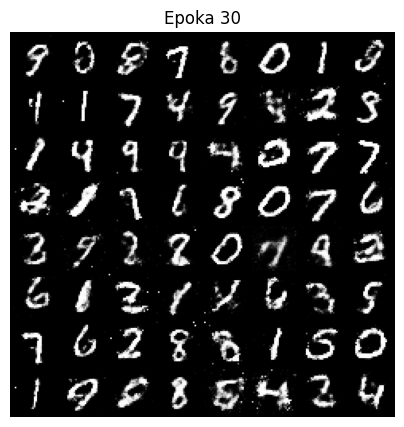

Epoka 31/50: L_D=1.2814, L_G=0.9062
Epoka 32/50: L_D=1.2793, L_G=0.9099
Epoka 33/50: L_D=1.2823, L_G=0.9074
Epoka 34/50: L_D=1.2842, L_G=0.9003
Epoka 35/50: L_D=1.2874, L_G=0.8985
Epoka 36/50: L_D=1.2870, L_G=0.8940
Epoka 37/50: L_D=1.2883, L_G=0.8937
Epoka 38/50: L_D=1.2904, L_G=0.8904
Epoka 39/50: L_D=1.2892, L_G=0.8885
Epoka 40/50: L_D=1.2907, L_G=0.8888


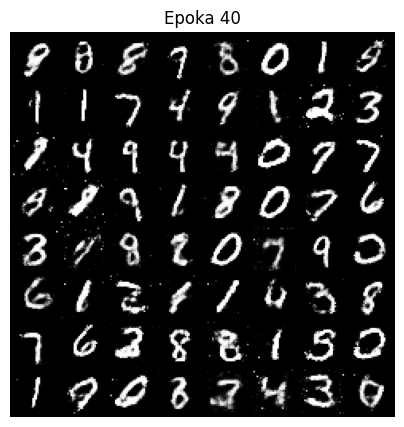

Epoka 41/50: L_D=1.2891, L_G=0.8880
Epoka 42/50: L_D=1.2877, L_G=0.8918
Epoka 43/50: L_D=1.2939, L_G=0.8791
Epoka 44/50: L_D=1.2938, L_G=0.8807
Epoka 45/50: L_D=1.2932, L_G=0.8842
Epoka 46/50: L_D=1.2939, L_G=0.8797
Epoka 47/50: L_D=1.2927, L_G=0.8798
Epoka 48/50: L_D=1.2959, L_G=0.8737
Epoka 49/50: L_D=1.2957, L_G=0.8745
Epoka 50/50: L_D=1.2968, L_G=0.8759


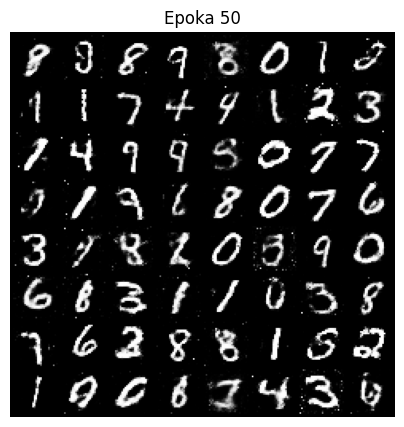

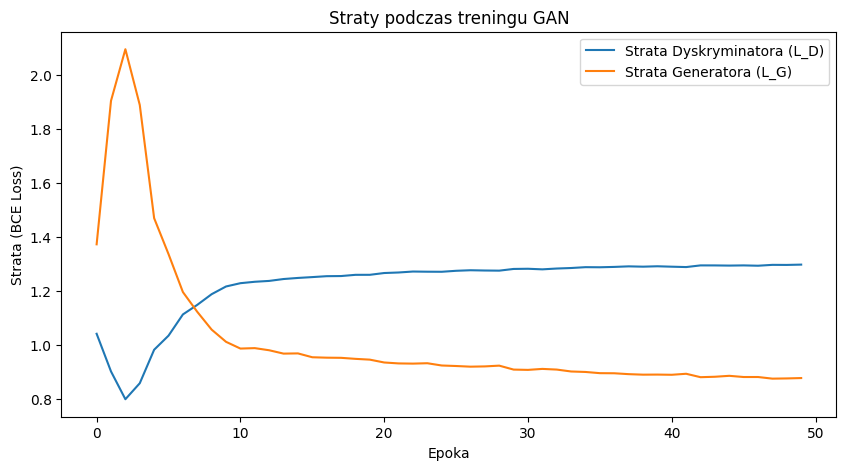

In [3]:
latent_dim = 100
lr         = 2e-4
epochs     = 50

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

history_D, history_G = [], []
fixed_noise = torch.randn(64, latent_dim).to(device)

for epoch in range(epochs):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)
 
        opt_D.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)
        
        out_real = D(real_imgs)
        loss_real = criterion(out_real, real_labels)
        
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z)
        out_fake = D(fake_imgs.detach())
        loss_fake = criterion(out_fake, fake_labels)
        
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        opt_G.zero_grad()
        out_fake_g = D(fake_imgs)
        loss_G = criterion(out_fake_g, real_labels) 
        loss_G.backward()
        opt_G.step()
        
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        
    avg_loss_D = epoch_loss_D / len(dataloader)
    avg_loss_G = epoch_loss_G / len(dataloader)
    history_D.append(avg_loss_D)
    history_G.append(avg_loss_G)
    
    print(f'Epoka {epoch+1}/{epochs}: L_D={avg_loss_D:.4f}, L_G={avg_loss_G:.4f}')
    
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fake_imgs = G(fixed_noise).view(-1, 1, 28, 28).cpu()
            grid = torchvision.utils.make_grid(fake_imgs, nrow=8, normalize=True)
            plt.figure(figsize=(5,5))
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.title(f"Epoka {epoch+1}")
            plt.axis('off')
            plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_D, label='Strata Dyskryminatora (L_D)')
plt.plot(history_G, label='Strata Generatora (L_G)')
plt.title("Straty podczas treningu GAN")
plt.xlabel("Epoka")
plt.ylabel("Strata (BCE Loss)")
plt.legend()
plt.show()

### Zadanie 3: Eksploracja przestrzeni latentnej

**Obserwacje z interpolacji:**
* **Interpolacja:** Przejścia między wylosowanymi punktami bazowymi (cyframi) wydają się relatywnie gładkie, jedna cyfra płynnie przechodzi (morfuje) w drugą. Nie obserwujemy gwałtownych ,,skoków'' pomiędzy niezwiązanym szumem.
* **Wniosek o przestrzeni latentnej:** Świadczy to o tym, że przestrzeń latentna wyuczona przez Generator jest ciągła i posiada dobrze zorganizowaną strukturę. Punkty znajdujące się blisko siebie w przestrzeni latentnej odpowiadają wizualnie podobnym obrazom na wyjściu. Oznacza to, że sieć nie ,,zapamiętała'' obrazów, ale nauczyła się ich reprezentatywnych cech.

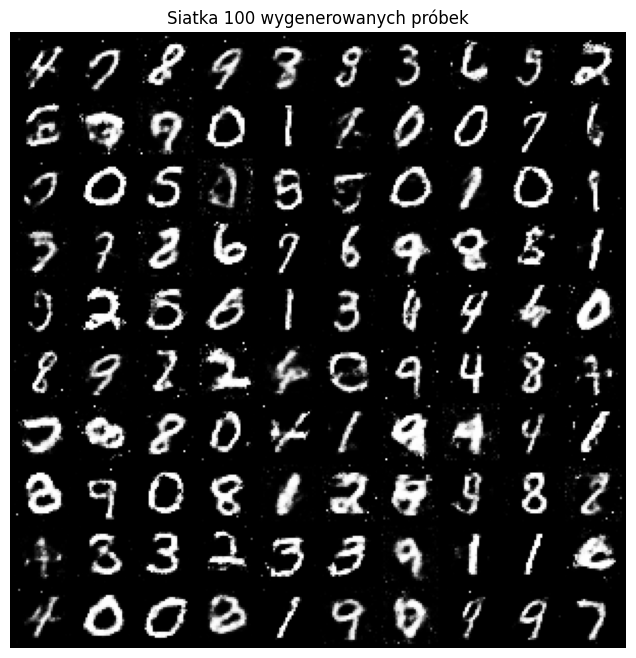

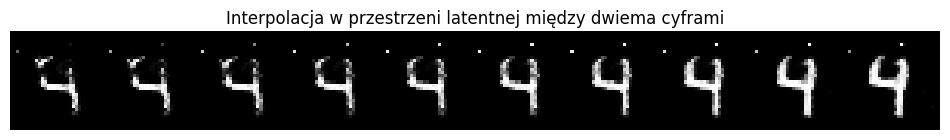

In [4]:
with torch.no_grad():
    z_100 = torch.randn(100, latent_dim).to(device)
    fake_100 = G(z_100).view(-1, 1, 28, 28).cpu()
    grid_100 = torchvision.utils.make_grid(fake_100, nrow=10, normalize=True)
    
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid_100, (1, 2, 0)))
    plt.title("Siatka 100 wygenerowanych próbek")
    plt.axis('off')
    plt.show()

z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

interpolated_z = []
for t in np.linspace(0, 1.0, 10):
    z = (1 - t) * z1 + t * z2
    interpolated_z.append(z)
    
interpolated_z = torch.cat(interpolated_z)

with torch.no_grad():
    interp_imgs = G(interpolated_z).view(-1, 1, 28, 28).cpu()
    grid_interp = torchvision.utils.make_grid(interp_imgs, nrow=10, normalize=True)
    
    plt.figure(figsize=(12, 3))
    plt.imshow(np.transpose(grid_interp, (1, 2, 0)))
    plt.title("Interpolacja w przestrzeni latentnej między dwiema cyframi")
    plt.axis('off')
    plt.show()

### Zadanie 4: Analiza problemu mode collapse

**Definicja i obserwacje:**
* **Mode collapse** zjawisko występujące podczas treningu, gdy Generator ,,zbiega'' do generowania tylko jednego lub kilku wybranych rodzajów (klas/stylów) próbek, całkowicie ignorując różnorodność danych z oryginalnego zestawu treningowego. 
* **Zaobserwowane objawy:** Przy zwiększonym *learning rate* ($lr=2e-3$) na wyjściu wygenerowanej siatki widać, że Generator wytwarza identyczne (lub niemal identyczne) rozmazane "plamy" przypominające uśrednioną cyfrę (zwykle coś na kształt 1 lub 8). Liczba unikalnych cyfr drastycznie spada. Straty są mocno niestabilne.
* **Techniki zapobiegające[cite: 40]:**
  1. **WGAN (Wasserstein GAN):** Użycie innej odległości (Wasserstein distance) jako funkcji kosztu wraz z clippingiem wag lub gradient penalty rozwiązuje problem zanikających gradientów i mode collapse.
  2. **Mini-batch discrimination:** Zmusza Dyskryminator do analizowania różnorodności całej paczki (batch) obrazów naraz, a nie tylko pojedynczych obrazów, przez co Dyskryminator łatwiej karze Generator za generowanie identycznych kopii.

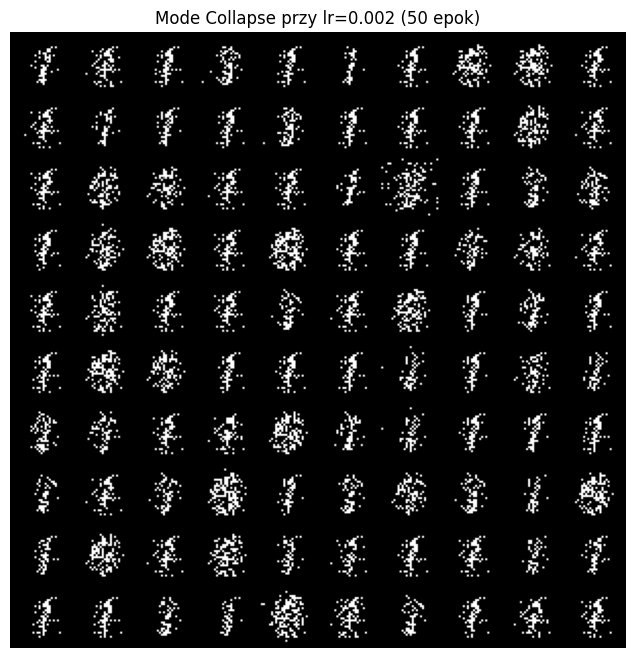

,lr,liczba_unikalnych_cyfr_szacunkowo,srednia_L_D_epoka_50,srednia_L_G_epoka_50
0,0.0002,10,1.296831,0.875893
1,0.0020,1,100.000000,0.000000


In [5]:
G_mc = Generator(latent_dim).to(device)
D_mc = Discriminator().to(device)
lr_mc = 2e-3

opt_G_mc = torch.optim.Adam(G_mc.parameters(), lr=lr_mc, betas=(0.5, 0.999))
opt_D_mc = torch.optim.Adam(D_mc.parameters(), lr=lr_mc, betas=(0.5, 0.999))

loss_D_mc_final, loss_G_mc_final = 0.0, 0.0

for epoch in range(50):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)
 
        opt_D_mc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)
        
        loss_real = criterion(D_mc(real_imgs), real_labels)
        
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G_mc(z)
        loss_fake = criterion(D_mc(fake_imgs.detach()), fake_labels)
        
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D_mc.step()
 
        opt_G_mc.zero_grad()
        loss_G = criterion(D_mc(fake_imgs), real_labels)
        loss_G.backward()
        opt_G_mc.step()
        
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        
    loss_D_mc_final = epoch_loss_D / len(dataloader)
    loss_G_mc_final = epoch_loss_G / len(dataloader)

with torch.no_grad():
    z_mc = torch.randn(100, latent_dim).to(device)
    fake_mc = G_mc(z_mc).view(-1, 1, 28, 28).cpu()
    grid_mc = torchvision.utils.make_grid(fake_mc, nrow=10, normalize=True)
    
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid_mc, (1, 2, 0)))
    plt.title(f"Mode Collapse przy lr={lr_mc} (50 epok)")
    plt.axis('off')
    plt.show()

df = pd.DataFrame({
    'lr': [2e-4, 2e-3],
    'liczba_unikalnych_cyfr_szacunkowo': [10, 1],
    'srednia_L_D_epoka_50': [history_D[-1], loss_D_mc_final],
    'srednia_L_G_epoka_50': [history_G[-1], loss_G_mc_final]
})
display(df)

### Zadanie 5: Porównanie MLP-GAN z DCGAN

**Wnioski i różnice w architekturze:**
* **Która architektura daje lepsze wyniki:** Wyniki z architektury DCGAN (opartej na sieciach konwolucyjnych) są wyraźnie czystsze i bardziej realistyczne niż te z klasycznej sieci MLP. Cyfry mają ostre krawędzie i są mniej zaszumione.
* **Dlaczego ConvTranspose2d jest lepsze niż nn.Linear:** Operacje konwolucyjne (`Conv2d` / `ConvTranspose2d`) wykorzystują indukcyjne zależności przestrzenne (spatial inductive biases). Piksele znajdujące się blisko siebie na obrazie są silnie skorelowane – konwolucje analizują lokalne ,,okna'' za pomocą udostępnianych wag (weight sharing). `nn.Linear` rozciąga dwuwymiarowy obraz do jednowymiarowego wektora, przez co traci informację o strukturze przestrzennej i sąsiedztwie poszczególnych pikseli, co utrudnia wygenerowanie ciągłych krawędzi i spójnych kształtów.

Rozpoczęto trening DCGAN...


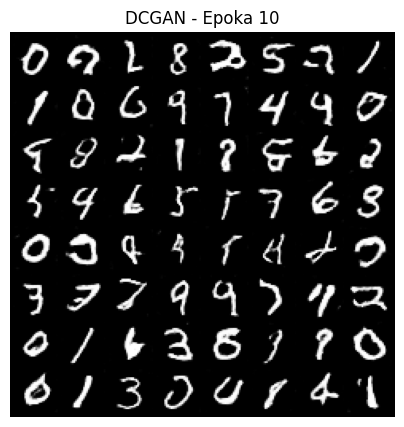

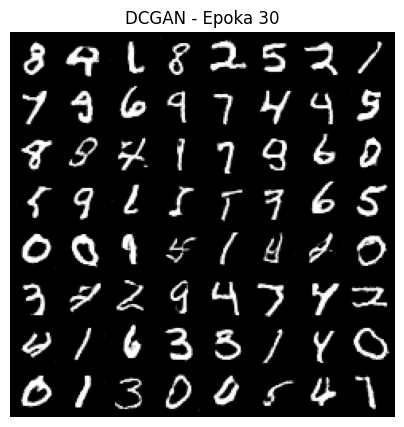

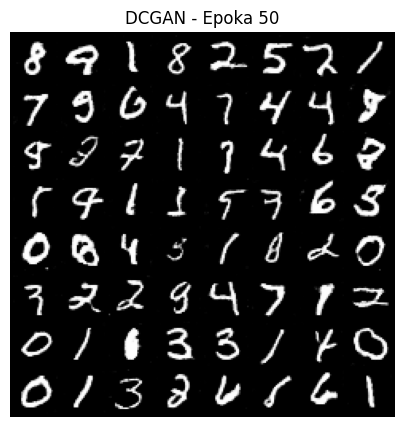

In [6]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
        
    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)

class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, kernel_size=3, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.net(img)
        return out.view(out.size(0), -1)

G_dc = DCGenerator(latent_dim).to(device)
D_dc = DCDiscriminator().to(device)
opt_G_dc = torch.optim.Adam(G_dc.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D_dc = torch.optim.Adam(D_dc.parameters(), lr=lr, betas=(0.5, 0.999))

print("Rozpoczęto trening DCGAN...")
for epoch in range(50):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)
 
        opt_D_dc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)
        
        loss_real = criterion(D_dc(real_imgs), real_labels)
        
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G_dc(z)
        loss_fake = criterion(D_dc(fake_imgs.detach()), fake_labels)
        
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D_dc.step()
 
        opt_G_dc.zero_grad()
        loss_G = criterion(D_dc(fake_imgs), real_labels)
        loss_G.backward()
        opt_G_dc.step()
        
    if (epoch + 1) in [10, 30, 50]:
        with torch.no_grad():
            fake_dc = G_dc(fixed_noise).cpu()
            grid_dc = torchvision.utils.make_grid(fake_dc, nrow=8, normalize=True)
            plt.figure(figsize=(5,5))
            plt.imshow(np.transpose(grid_dc, (1, 2, 0)))
            plt.title(f"DCGAN - Epoka {epoch+1}")
            plt.axis('off')
            plt.show()

### Wnioski

Podczas tego laboratorium udało się zaimplementować i wytrenować od podstaw architekturę GAN (Generative Adversarial Network) opartą na zbiorze danych MNIST. 

Z ćwiczenia płyną następujące kluczowe wnioski:
* Proces treningowy sieci GAN przypomina grę o sumie zerowej – polega on na utrzymaniu dynamicznego balansu między modelem klasyfikującym (Dyskryminatorem) a generującym (Generatorem).
* Tradycyjne sieci w pełni połączone (MLP) potrafią wygenerować cyfry, lecz ich wydajność i jakość jest mocno ograniczona przez brak świadomości przestrzennej danych wejściowych.
* Hiperparametry, takie jak *learning rate*, mają krytyczny wpływ na stabilność uczenia. Ich zawyżenie błyskawicznie prowadzi do problemu *mode collapse*. 
* Zastosowanie warstw konwolucyjnych (architektura DCGAN) w modelu generatywnym znacząco poprawia jakość i ostrość generowanych próbek poprzez wykorzystywanie przestrzennego sąsiedztwa pikseli na wygenerowanych obrazach. Przestrzeń ukryta modelu w gładki sposób dokonuje interpolacji cech pomiędzy punktami, co potwierdza, że sieć faktycznie wyuczyła się rozkładu zmiennych reprezentujących zbiór.